# Cross-resistance on the allele-frequency dataset

> **What the graphs show.** This panel reproduces the same shared-driver edges as the original dataset (`burden_f420_activation` -> delamanid/pretomanid, efflux variants -> bedaquiline/clofazimine). The agnostic joint graph also throws up one feature (`mtra_Leu120Arg`) that points into every drug at once. The linezolid control flags this as an artifact rather than a real driver (see below).

See [README.md](README.md) for how to read these graphs, the reliability number, the node colours, the pooled burdens, and the modelling choices.

Same design as the original-data cross-resistance notebook. The only change is how features are built: mutations are allele frequencies turned into 0/1 at a >= 5% threshold, over a wider gene panel that adds the regulatory genes `ndh`, `mtrA`, `mtrB`, `lpqB`. A wider panel can surface new drivers, but can also let in features that just track how strains are grouped rather than resistance itself. Catching that is exactly what the linezolid negative control is for.

Resistance *type* is excluded for the same reason as before: the type label is defined from resistance to other drugs, so it sits below those MICs rather than above them.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[2]))
from src.causal_discovery.cmm_utils import show_graph, parents_of, parents_across, plot_parents_across

/Users/yasmineparent/internship/tb_internship/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yasmineparent/internship/tb_internship/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## Joint graph, all drugs (agnostic)

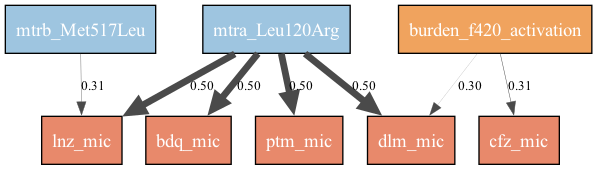

In [2]:
show_graph('tb_multidrug_freq_dlm_ptm_bdq_cfz_lnz', ['dlm_mic','ptm_mic','bdq_mic','cfz_mic','lnz_mic'], 0.3)

## Complete structure (mutation -> lineage co-occurrence)

The same joint graph with `into_only=False`, adding the background edges the focused views drop, in particular mutation -> lineage. An arrow from a mutation into a lineage just means they co-occur; nothing ever points from lineage into a mutation.

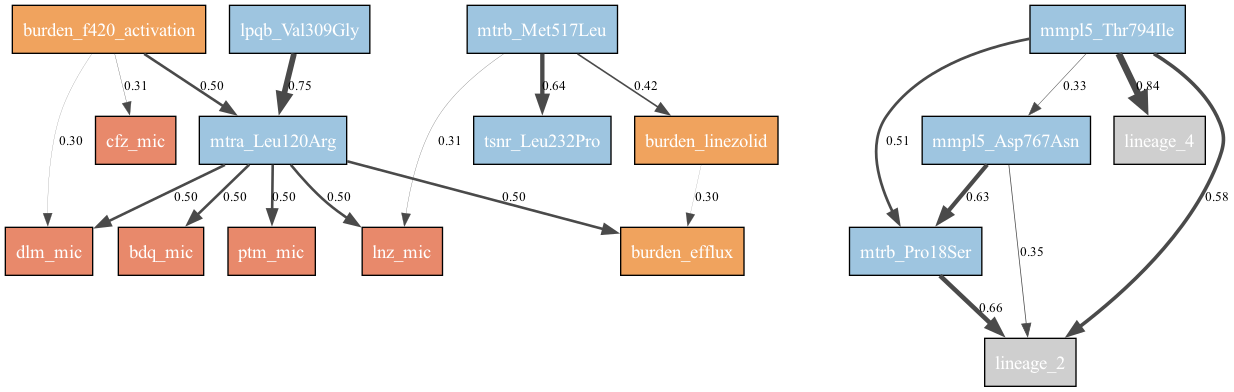

In [3]:
show_graph('tb_multidrug_freq_dlm_ptm_bdq_cfz_lnz', ['dlm_mic','ptm_mic','bdq_mic','cfz_mic','lnz_mic'], 0.3, into_only=False)

## The negative control catches an artifact

Linezolid has no resistant strains in this dataset, so its MIC barely varies and nothing can genuinely drive it. That is exactly why it is kept in the graph as a **negative control**: any feature that shows up as a driver of `lnz_mic` must be picking up something other than resistance.

In the joint graph, `mtra_Leu120Arg` points into **all five** MICs at 0.50, `lnz_mic` included. Two things give it away: its plain correlation with each MIC is about 0 (so it is not really predicting resistance levels), and it points into every drug equally, including the one that cannot be driven.

What it is actually doing is labelling a subgroup of strains: it co-occurs with `lpqb_Val309Gly` and follows the lineage column. A variable that splits the samples into groups like this can get selected as a "parent" of many nodes at once, just because it helps partition the data, without driving any of them. The linezolid edge is the tell: a real resistance signal cannot run through a drug with no resistance, so the whole pan-drug pattern is population structure, not cross-resistance.

The point is methodological: this artifact comes from the newly added regulatory genes, so they need vetting before they can be trusted in an agnostic (hypothesis-free) graph.

## Focused graphs replicate the findings

Dropping the new regulatory genes, the focused per-group graphs hold up, and sharpen, under frequency calling.

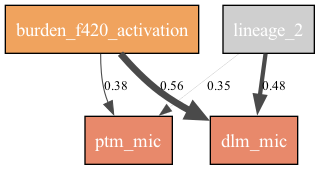

In [4]:
show_graph('tb_multidrug_freq_focused_f420_dlm_ptm', ['dlm_mic', 'ptm_mic'])

In [5]:
parents_of('tb_multidrug_freq_focused_f420_dlm_ptm', 'dlm_mic')

,source,frequency
0,burden_f420_activation,0.56
1,lineage_2,0.48
2,lineage_4,0.18


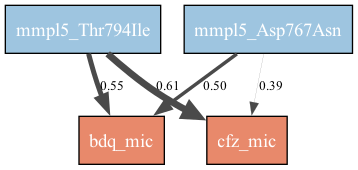

In [6]:
show_graph('tb_multidrug_freq_focused_efflux_bdq_cfz', ['bdq_mic', 'cfz_mic'])

In [7]:
parents_of('tb_multidrug_freq_focused_efflux_bdq_cfz', 'bdq_mic')

,source,frequency
0,mmpl5_Thr794Ile,0.55
1,mmpl5_Asp767Asn,0.50
2,burden_efflux,0.29
3,pepq_Ala87Gly,0.26
4,lineage_4,0.15
5,lineage_2,0.10


## Reading the results

- Focused `burden_f420_activation -> delamanid` replicates (reliability ~0.56) and reaches pretomanid.
- The efflux edge sharpens: `mmpl5_Thr794Ile` now clears 0.5 into both bedaquiline and clofazimine, a single clean shared-driver edge.
- Trust the focused graphs on this panel. The agnostic joint graph here is confounded by the regulatory-gene artifact above, so the frequency data helps the focused, per-group graphs more than the agnostic one.